# Import dataset from roboflow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="place your api key here")
project = rf.workspace("ahmad-elhamshary").project("football-4g4sh-lp9vn")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-1 in yolov11:: 100%|██████████| 41131/41131 [00:08<00:00, 4941.23it/s]


# Import needed libraries

In [2]:
!pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.6 MB/s eta 0:00:00


# Download the model (YOLO)

In [3]:
! wget https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n.pt

--2026-07-04 22:09:16--  https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n.pt
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/b7314782-9dd4-4bb5-a3bd-5b62195f3b73?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-04T22%3A59%3A51Z&rscd=attachment%3B+filename%3Dyolo11n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-04T21%3A59%3A31Z&ske=2026-07-04T22%3A59%3A51Z&sks=b&skv=2018-11-09&sig=9KJWqreMWn1855qytwmc5mMH%2F3ee7%2BnzFA1vKYyNdXE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MzIwMzI1NiwibmJmIjoxNzgzMjAyOTU2LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvc

# Run the model

In [4]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model.train(
    data=r'/content/football-1/data.yaml',
    epochs = 20,
    imgsz = 640,
    batch = 16,
    name = 'custom_yolov11n_train',
    patience = 5

)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7,

# Evaluation metrics

In [5]:
metrics = model.val()

print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"mAP@50:95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.p.mean():.3f}")
print(f"Recall: {metrics.box.r.mean():.3f}")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1220.3±445.9 MB/s, size: 35.8 KB)
val: Scanning /content/football-1/valid/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 44.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2it/s 8.5s
                   all        150       2523      0.894      0.849      0.844      0.485
                  ball        121        125      0.712      0.396      0.387      0.145
            goalkeeper         24         24      0.934      0.958       0.92      0.535
               referee        130        238      0.917      0.983      0.968      0.595
                team 1        150       1085      0.962      0.963      0.981      0.584
                team 2        144       105

# Test Case


image 1/1 /content/football-1/test/images/00379c179c58465abeb662e28b8d630006_png.rf.a15dbfe48cf27d0df163e52124b01c09.jpg: 640x640 1 team 1, 8.7ms
Speed: 3.9ms preprocess, 8.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
1 label saved to /content/runs/detect/predict/labels


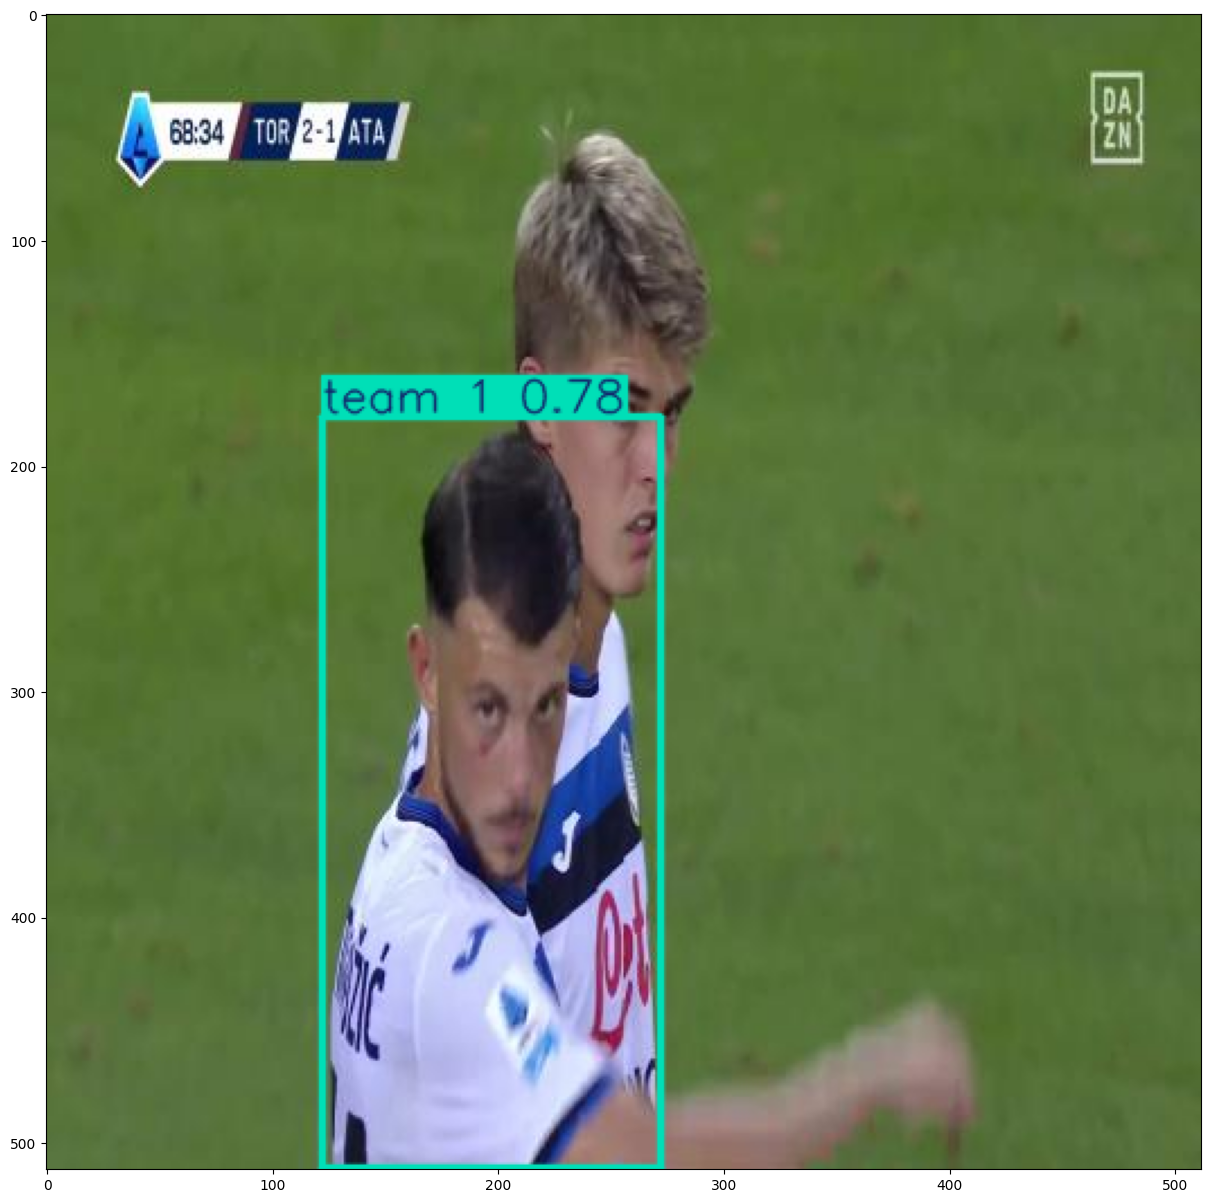

In [6]:
import matplotlib.pyplot as plt
import cv2

results = model.predict(
    source = '/content/football-1/test/images/00379c179c58465abeb662e28b8d630006_png.rf.a15dbfe48cf27d0df163e52124b01c09.jpg',
    save = True,
    save_txt = True,
    conf = 0.5,
    iou = 0.45
)

plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
plt.show()